# Talento Altamente Especializado (TAE) en Inteligencia Artificial
## Módulo 4 — Notebook 2.3: Deep Neural Networks

**Nombre:** Alejandro Campos Martínez  
**Módulo:** 4  
**Programa:** Talento Altamente Especializado (TAE) en Inteligencia Artificial  
**Instructor:** German Alonso Pinedo Diaz  
**Lugar:** Tepic, Nayarit  
**Fecha:** 4 de julio de 2026

---

# Talento Altamente Especializado (TAE) en Inteligencia Artificial
## Módulo 4 — Notebook 2.3: Deep Neural Networks

**Nombre:** Alejandro Campos Martínez  
**Módulo:** 4  
**Programa:** Talento Altamente Especializado (TAE) en Inteligencia Artificial  
**Instructor:** German Alonso Pinedo Diaz  
**Lugar:** Tepic, Nayarit  
**Fecha:** 18 de julio de 2026

---

# **Convolución 1D**

Este cuaderno explora las capas convolucionales 1D.

Ejecuta las celdas en orden. En varios lugares verás la palabra "TAREA": sigue esas instrucciones, anticipa qué ocurrirá o escribe el código necesario para completar las funciones.


**Nota**

En estas funciones usaremos la convención habitual de dilatación: una dilatación de 1 aplica el filtro sobre elementos contiguos; una dilatación de 2 deja un espacio entre elementos consecutivos del filtro.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define una señal a la que aplicaremos convolución
x = [5.2, 5.3, 5.4, 5.1, 10.1, 10.3, 9.9, 10.3, 3.2, 3.4, 3.3, 3.1]

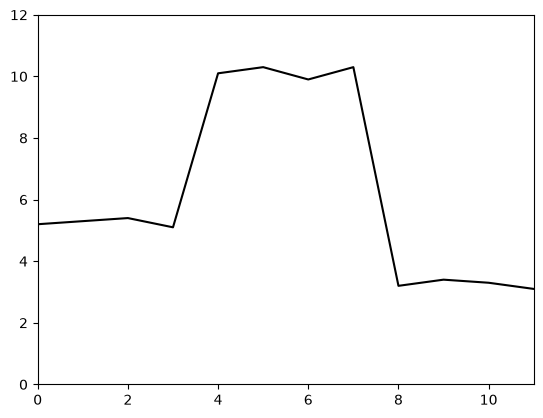

In [3]:
# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
plt.show()

In [4]:
# Definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 3, paso 1 y dilatación 1.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
# Recuerda que los arreglos de Python se indexan desde cero.
def conv_3_1_1_zp(x_in, omega):
    x_in = np.array(x_in, dtype=float)
    x_out = np.zeros_like(x_in)
    x_pad = np.concatenate(([0.0], x_in, [0.0]))   # un cero a cada lado
    for i in range(len(x_in)):
        x_out[i] = omega[0]*x_pad[i] + omega[1]*x_pad[i+1] + omega[2]*x_pad[i+2]
    


    return x_out

Ahora veamos qué tipo de operaciones puede hacer una convolución.
Primero puede promediar valores cercanos y suavizar la función:

La suma de la salida es 71.1, debe ser 71.1


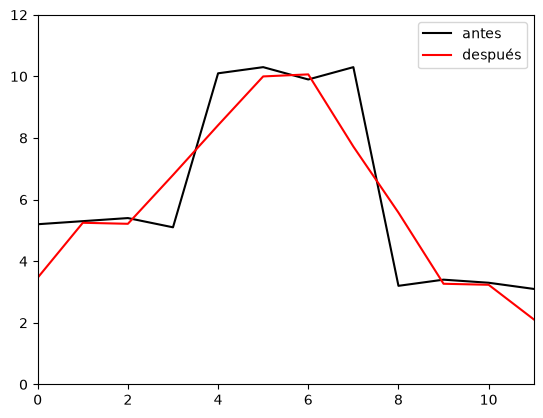

In [5]:

omega = [0.33,0.33,0.33]
h = conv_3_1_1_zp(x, omega)

# Comprueba que lo calculaste correctamente
print(f"La suma de la salida es {np.sum(h):3.3}, debe ser 71.1")

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h, 'r-',label='después')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

Observa que la función roja es una versión suavizada de la negra, porque promedia valores adyacentes. Sin embargo, las primeras y últimas salidas son bastante menores que la curva original. Asegúrate de entender por qué.<br><br>

Con pesos diferentes, la convolución puede detectar cambios bruscos en la función:

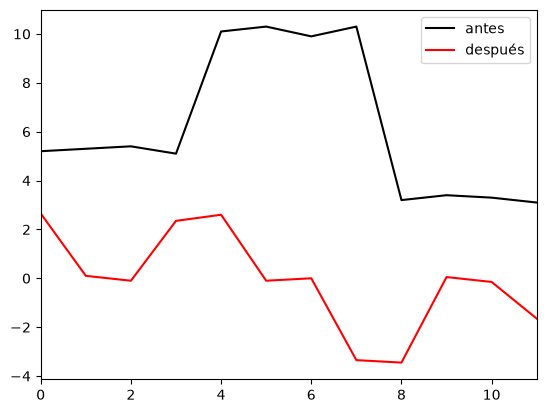

In [6]:

omega = [-0.5,0,0.5]
h2 = conv_3_1_1_zp(x, omega)

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h2, 'r-',label='después')
ax.set_xlim(0,11)
# ax.set_ylim(0, 12)
ax.legend()
plt.show()

Observa que la convolución produce un pico donde la función original sube y un valle donde baja. Es aproximadamente cero donde la función es localmente plana; por eso esta convolución aproxima una derivada. <br><br>

Ahora definamos algunas convoluciones con distintos parámetros.

In [7]:
# Definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 3, paso 2 y dilatación 1.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
def conv_3_2_1_zp(x_in, omega):
    x_in = np.array(x_in, dtype=float)
    x_out = np.zeros(int(np.ceil(len(x_in)/2)))
    x_pad = np.concatenate(([0.0], x_in, [0.0]))
    for j in range(len(x_out)):
        i = 2*j                                    # el paso 2 va en la entrada
        x_out[j] = omega[0]*x_pad[i] + omega[1]*x_pad[i+1] + omega[2]*x_pad[i+2]



    return x_out

In [8]:
omega = [0.33,0.33,0.33]
h3 = conv_3_2_1_zp(x, omega)

# Si lo hiciste bien, la longitud de salida debe ser seis y debe
# contener uno de cada dos valores de la convolución original con paso 1
print(h)
print(h3)

[ 3.465  5.247  5.214  6.798  8.415  9.999 10.065  7.722  5.577  3.267
  3.234  2.112]
[ 3.465  5.214  8.415 10.065  5.577  3.234]


In [9]:
# Definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 5, paso 1 y dilatación 1.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
def conv_5_1_1_zp(x_in, omega):
    x_in = np.array(x_in, dtype=float)
    x_out = np.zeros_like(x_in)
    # TAREA -- escribe esta función
    # reemplaza esta línea
    x_pad = np.concatenate(([0.0, 0.0], x_in, [0.0, 0.0]))   # dos ceros por lado
    for i in range(len(x_in)):
        x_out[i] = sum(omega[k] * x_pad[i+k] for k in range(5))



    return x_out

La suma de la salida es 69.6, debe ser 69.6


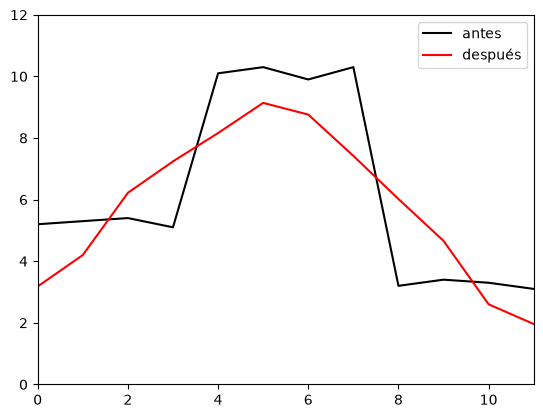

In [10]:

omega2 = [0.2, 0.2, 0.2, 0.2, 0.2]
h4 = conv_5_1_1_zp(x, omega2)

# Comprueba que lo calculaste correctamente
print(f"La suma de la salida es {np.sum(h4):3.3}, debe ser 69.6")

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h4, 'r-',label='después')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

In [11]:
# Finalmente, definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 3, paso 1 y dilatación 2.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
# Recuerda que los arreglos de Python se indexan desde cero.
def conv_3_1_2_zp(x_in, omega):
    x_in = np.array(x_in, dtype=float)
    x_out = np.zeros_like(x_in)
    # TAREA -- escribe esta función
    # reemplaza esta línea
    x_pad = np.concatenate(([0.0, 0.0], x_in, [0.0, 0.0]))
    for i in range(len(x_in)):
        x_out[i] = omega[0]*x_pad[i] + omega[1]*x_pad[i+2] + omega[2]*x_pad[i+4]


    return x_out

La suma de la salida es 68.3, debe ser 68.3


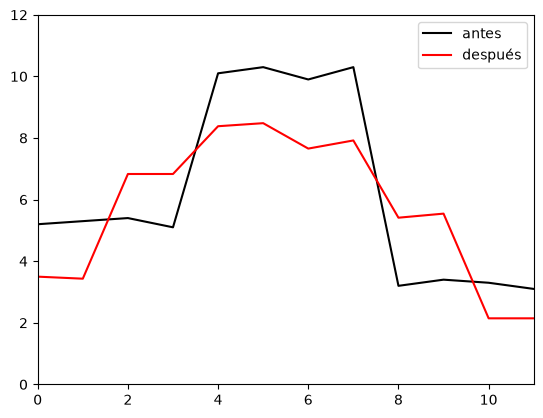

In [12]:
omega = [0.33,0.33,0.33]
h5 = conv_3_1_2_zp(x, omega)

# Comprueba que lo calculaste correctamente
print(f"La suma de la salida es {np.sum(h5):3.3}, debe ser 68.3")

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h5, 'r-',label='después')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

Finalmente, representemos las convoluciones como matrices completas y comprobemos que obtenemos el mismo resultado.

In [17]:
# Calcula la matriz de convolución
def get_conv_mat_3_1_1_zp(n_out, omega):
    omega_mat = np.zeros((n_out, n_out))
  # TAREA: completa esta matriz
  # Reemplaza esta línea:
    for i in range(n_out):
        if i-1 >= 0:
            omega_mat[i, i-1] = omega[0]
        omega_mat[i, i] = omega[1]
        if i+1 < n_out:
            omega_mat[i, i+1] = omega[2]
    return omega_mat

In [18]:
# Ejecuta la convolución original
omega = np.array([-1.0,0.5,-0.2])
h6 = conv_3_1_1_zp(x, omega)
print(h6)

# Si lo hiciste bien, deberías obtener la misma respuesta
omega_mat = get_conv_mat_3_1_1_zp(len(x), omega)
h7 = np.matmul(omega_mat, x)
print(h7)


[ 1.54 -3.63 -3.62 -4.87 -2.11 -6.93 -7.41 -5.39 -9.38 -2.16 -2.37 -1.75]
[ 1.54 -3.63 -3.62 -4.87 -2.11 -6.93 -7.41 -5.39 -9.38 -2.16 -2.37 -1.75]


TAREA: ¿Qué esperas que ocurra si aplicamos dos veces la última convolución? ¿Se puede representar como una sola convolución? Si es así, ¿cuál sería?

**Respuesta:** 

Aplicar la misma convolución dos veces equivale a una sola convolución con un kernel más grande.

Como la convolución es una multiplicación matricial, $\mathbf{h} = \Omega\,\mathbf{x}$, aplicarla dos veces es:

$$\Omega(\Omega\,\mathbf{x}) = \Omega^2\,\mathbf{x}$$

y $\Omega^2$ sigue siendo una matriz banda, solo que más ancha. Esto corresponde a un nuevo kernel obtenido al convolucionar el kernel original consigo mismo.

Regla general: componer un kernel de tamaño $k_1$ con uno de tamaño $k_2$ produce un kernel de tamaño $k_1 + k_2 - 1$. Aquí $3 + 3 - 1 = 5$.

Con $\omega = [-1.0,\ 0.5,\ -0.2]$, el kernel equivalente de tamaño 5 es:

$$[\,1.0,\quad -1.0,\quad 0.65,\quad -0.2,\quad 0.04\,]$$

Conclusión: sí se puede representar como una sola convolución, donde dos capas de kernel 3 tienen el mismo campo receptivo que una de kernel 5, pero con menos parámetros y una no linealidad intermedia que las hace más expresivas.